In [11]:
from PIL import Image
import numpy as np
import easyocr
import pytesseract
import cv2
from matplotlib import pyplot as plt
import os
import requests


In [2]:
reader = easyocr.Reader(['en'], gpu=False, verbose=False)
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

14
card1.webp


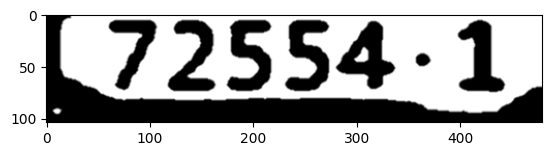

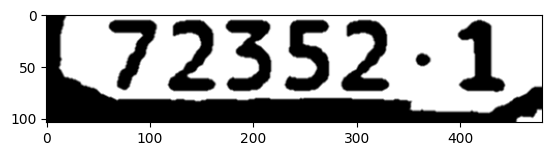

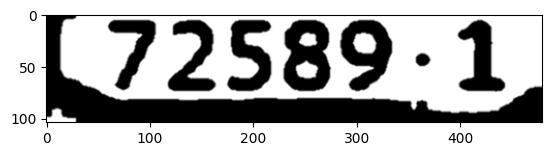

[72554, 72352, 72589]
card2.webp


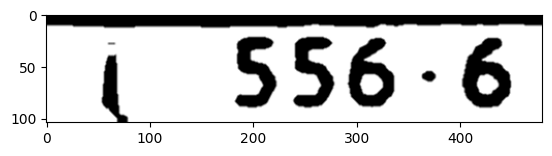

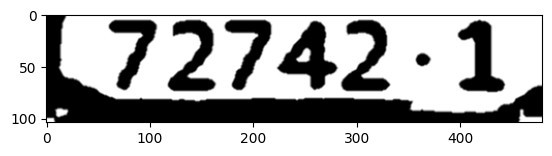

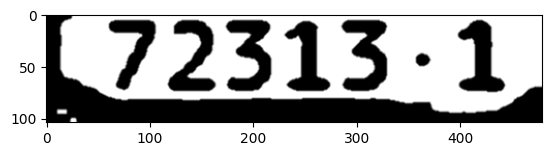

[556, 72742, 72313]
card3.webp


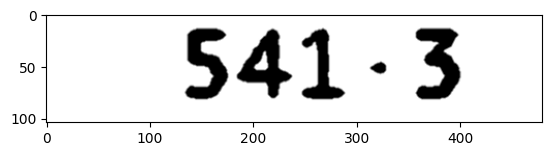

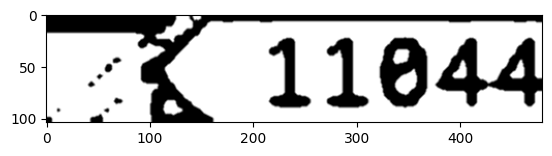

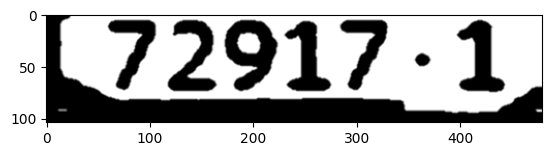

[541, 11044, 72917]
card4.webp


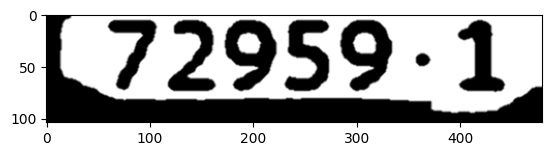

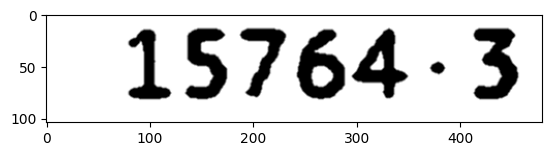

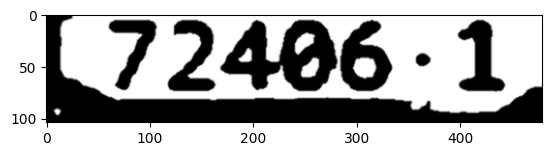

[72959, 15764, 72406]
card5.webp


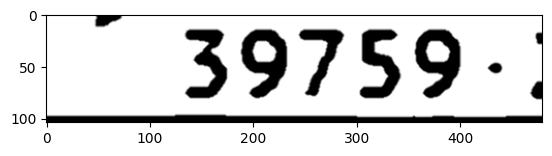

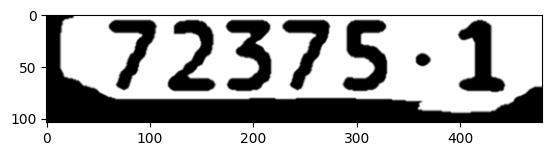

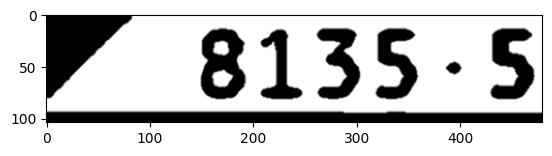

[39759, 72375, 8135]
card6.webp


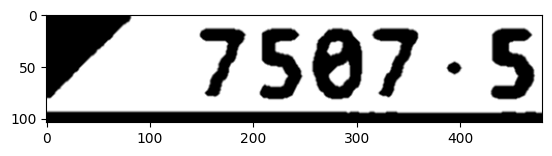

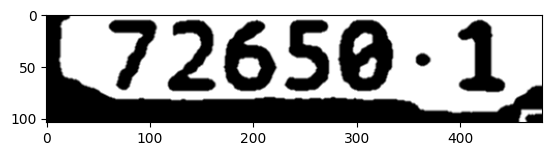

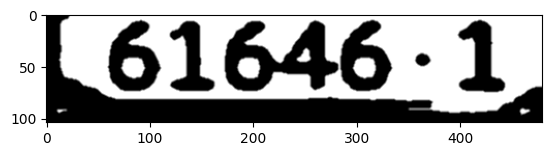

[7507, 72650, 61646]
card7.webp


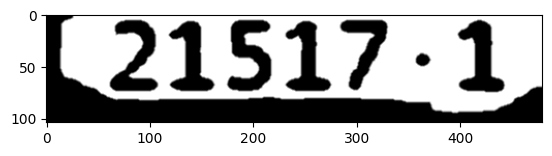

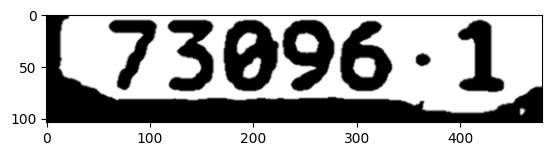

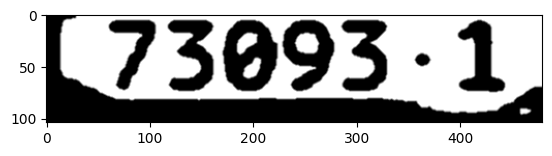

[21517, 73096, 73093]
card8.webp


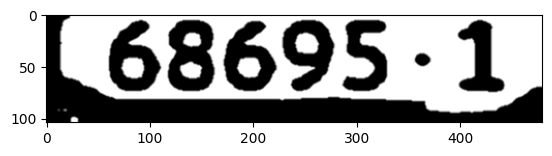

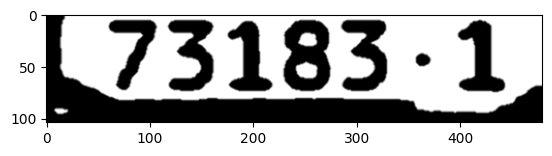

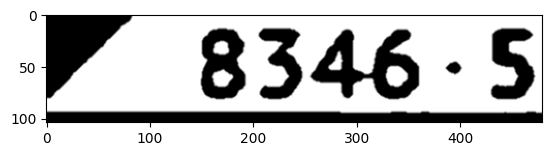

[68695, 73183, 8346]
card9.webp


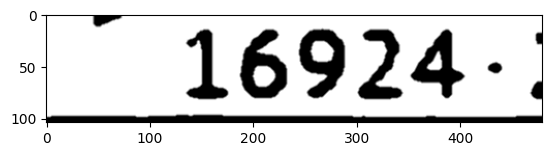

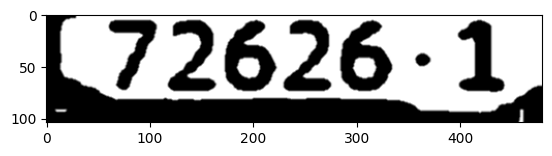

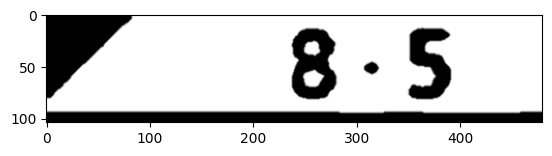

[16924, 72626, 8]
card10.webp


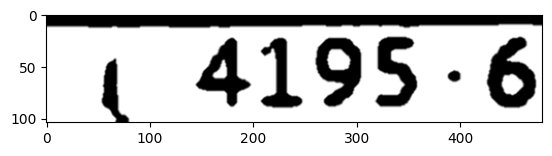

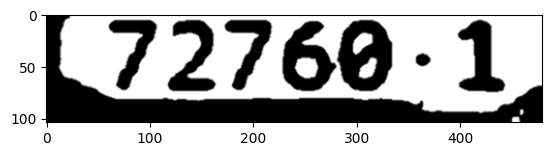

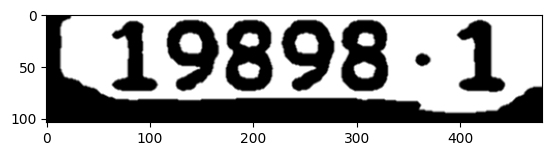

[4195, 72760, 19898]
card11.webp


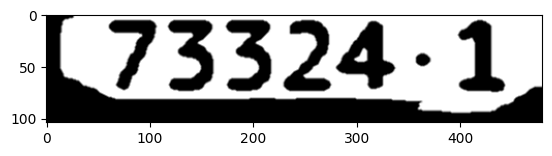

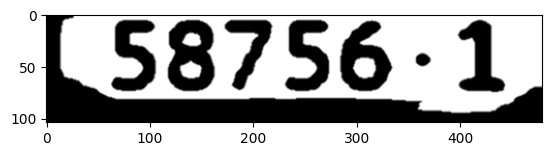

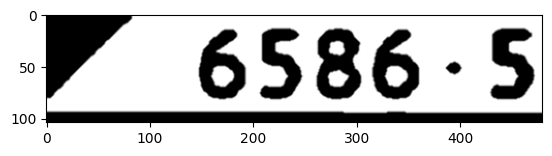

[73324, 58756, 6586]
card12.webp


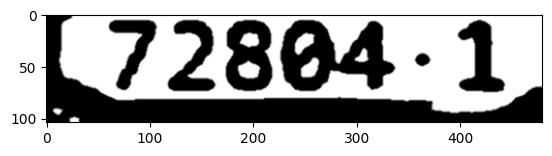

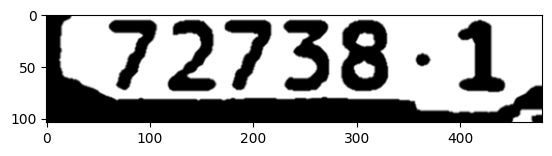

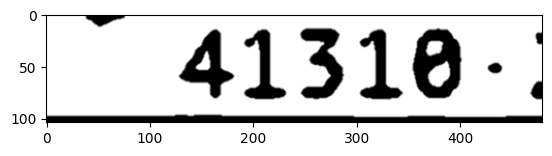

[72804, 72738, 41310]
card13.webp


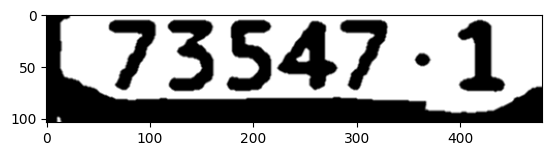

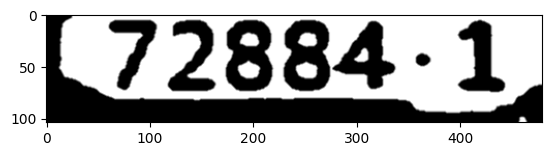

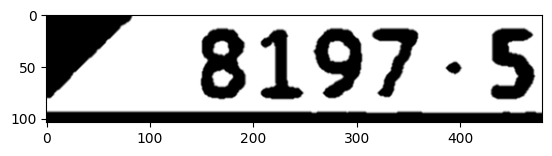

[73547, 72884, 8197]
card14.webp


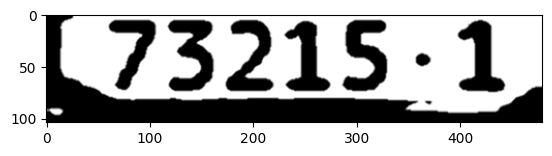

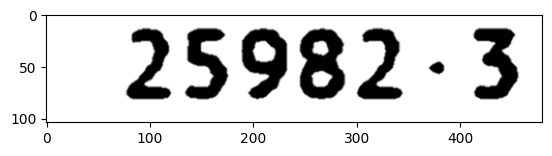

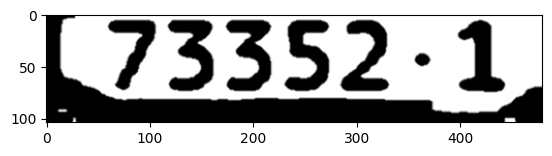

[73215, 25982, 73352]


In [10]:
def unsharp_mask(image, kernel_size=(5, 5), sigma=1.0, amount=1.0, threshold=0):
    """Return a sharpened version of the image, using an unsharp mask."""
    blurred = cv2.GaussianBlur(image, kernel_size, sigma)
    sharpened = float(amount + 1) * image - float(amount) * blurred
    sharpened = np.maximum(sharpened, np.zeros(sharpened.shape))
    sharpened = np.minimum(sharpened, 255 * np.ones(sharpened.shape))
    sharpened = sharpened.round().astype(np.uint8)
    if threshold > 0:
        low_contrast_mask = np.absolute(image - blurred) < threshold
        np.copyto(sharpened, image, where=low_contrast_mask)
    return sharpened


noOfFiles = len(os.listdir(f'cards\\'))
print(noOfFiles)

def ocr(image):
    numArr = []
    for i in range(0,3):
        length = 60
        if i == 0:
            x = 153
        elif i == 1:
            x = 427
        else:
            x = 701
        cropped = image[372:385, x:x+length]
        upscaled = cv2.resize(cropped, (0,0), fx = 8, fy = 8)
        gray = cv2.cvtColor(upscaled, cv2.COLOR_RGB2GRAY)
        _, thresholded = cv2.threshold(gray, 64, 255,
            cv2.THRESH_BINARY_INV)

        blurred = cv2.GaussianBlur(thresholded, (3, 3), 1)
        sharpened = unsharp_mask(blurred, kernel_size=(3,3))

        OcrImage = sharpened
        plt.imshow(OcrImage, cmap='gray')
        plt.show()
        results = reader.readtext(OcrImage, allowlist='0123456789. ', min_size = 5)
        numArr.append(int((results[0][1].lstrip().split(" ")[0].split(".")[0][:5])))
    return numArr


for j in range(1,noOfFiles+1):
    print(f'card{j}.webp')
    card_image = cv2.imread(f'cards\\card{j}.webp')
    card_num = ocr(card_image)
    print(card_num)




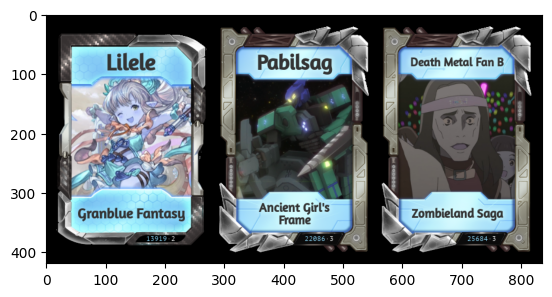

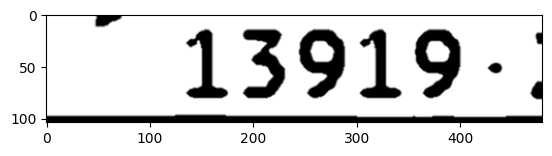

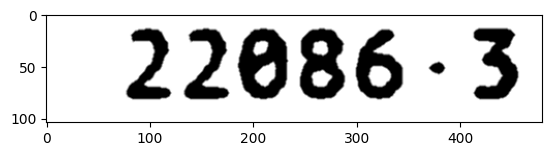

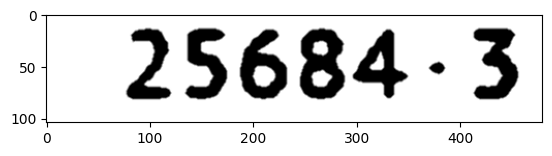

[13919, 22086, 25684]


In [ ]:
url = r'https://cdn.discordapp.com/attachments/1316412274734399528/1347882128733638686/card.webp?ex=67cd708d&is=67cc1f0d&hm=18b332d62b95c7dca22e2141d8d9922fb5a5541015c002e602e419e41c76e9ba&'
resp = requests.get(url, stream=True).raw
image = np.asarray(bytearray(resp.read()), dtype="uint8")
image = cv2.imdecode(image, cv2.IMREAD_COLOR)
plt.imshow(image)
plt.show()
card_num = ocr(image)
print(card_num)